# PAN Merchant Fraud Detection — EDA & Model Training

This notebook takes the two generated datasets:
- **`merchant_synthetic_100k.csv`** — 100,000 merchants with profile, transaction-behavior, shared-identifier, and graph-embedding features, plus the `is_fraud` label.
- **`merchant_edges.csv`** — the merchant-to-merchant connection list (shared PAN / device / IP), used to detect fraud rings.

**Notebook flow (each section is self-contained and easy to follow):**
1. Load data
2. Initial exploration (shapes, dtypes, class balance)
3. Missing value check & handling
4. Feature engineering (graph features from the edge list, date → recency, categorical encoding)
5. Exploratory Data Analysis (matplotlib + seaborn)
6. Train/test split
7. Model comparison (Logistic Regression, Random Forest, HistGradientBoosting)
8. Final model evaluation (confusion matrix, ROC curve, feature importance)
9. Conclusion

> 💡 Place both CSV files in the same folder as this notebook before running.


## 1. Imports

In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    confusion_matrix, roc_curve
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 60)


## 2. Load the Data

We load both CSV files generated by the data-generation notebook/pipeline.

In [4]:
merchants = pd.read_csv("merchant_synthetic_100k.csv")
edges = pd.read_csv("merchant_edges.csv")

print("Merchants dataset:", merchants.shape)
print("Edges dataset:", edges.shape)

merchants.head()


Merchants dataset: (100000, 34)
Edges dataset: (11015, 4)


,merchant_id,is_fraud,merchant_registration_date,merchant_category,business_city,merchant_tier,is_kyc_verified,pan_hash,device_id_hash,ip_hash,total_txns_90d,avg_txn_value,chargeback_rate,refund_ratio,merchant_age_days,total_txns_30d,total_txns_7d,avg_txn_value_30d,median_txn_value_90d,std_txn_value_90d,min_txn_value_30d,max_txn_value_30d,pct_high_value_txns,high_value_txns_90d,high_value_txns_30d,shared_pan_count,shared_device_count,shared_ip_count,phone_hash,email_hash,pos_terminal_id_hash,shared_phone_count,shared_email_count,shared_pos_terminal_count
0,M_0,0,2023-08-21T00:00:00,services,City_76,micro,1.0,PAN_C_12415,DEV_C_123009,IP_C_106139,15,398.890000,0.161400,0.0413,500,7.0,1,413.89,287.10,63.14,73.92,813.91,0.3716,5,2,1,1,0,PH_99005,EM_53955,POS_26789,2,0,1
1,M_1,0,2020-10-28T00:00:00,delivery,City_169,micro,1.0,PAN_C_67506,DEV_C_98240,IP_C_49617,3,1786.810000,0.025600,0.0964,134,1.0,0,1781.18,1987.48,217.43,643.74,3272.13,0.0403,0,0,1,0,1,PH_73282,EM_134913,POS_17945,0,0,2
2,M_2,0,2021-04-25T00:00:00,marketplace,City_174,medium,1.0,PAN_C_151819,DEV_C_24589,IP_C_110533,25,1347.592928,0.000062,0.0000,272,4.0,1,1630.57,1064.26,1015.57,224.44,5863.24,0.0080,0,0,1,2,0,PH_12346,EM_57267,POS_58788,0,0,0
3,M_3,0,2022-03-14T00:00:00,kirana,City_151,small,1.0,PAN_C_155845,DEV_C_128447,IP_C_94204,31,659.970000,0.069600,0.0112,1000,14.0,4,788.27,647.52,344.98,59.71,3357.78,0.1594,4,2,1,1,3,PH_183099,EM_173184,POS_21516,0,0,1
4,M_4,0,2022-03-23T00:00:00,delivery,City_154,small,0.0,PAN_C_88367,DEV_C_46490,IP_C_134539,1,1510.490000,0.011200,0.0057,608,0.0,0,1811.51,1084.93,608.48,620.26,2504.33,0.1256,0,0,0,3,2,PH_79082,EM_197384,POS_20664,0,0,1


In [5]:
edges.head()


,merchant_A,merchant_B,weight,reason
0,M_50614,M_68249,3,PAN
1,M_68249,M_28761,1,IP
2,M_28761,M_81614,3,PAN
3,M_81614,M_6856,1,IP
4,M_6856,M_26258,3,PAN


## 3. Initial Exploration

Basic shape, data types, summary statistics, and class balance — always the first
thing to check before doing anything else.

In [6]:
merchants.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 34 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   merchant_id                 100000 non-null  object 
 1   is_fraud                    100000 non-null  int64  
 2   merchant_registration_date  100000 non-null  object 
 3   merchant_category           100000 non-null  object 
 4   business_city               100000 non-null  object 
 5   merchant_tier               100000 non-null  object 
 6   is_kyc_verified             100000 non-null  float64
 7   pan_hash                    100000 non-null  object 
 8   device_id_hash              100000 non-null  object 
 9   ip_hash                     100000 non-null  object 
 10  total_txns_90d              100000 non-null  int64  
 11  avg_txn_value               100000 non-null  float64
 12  chargeback_rate             100000 non-null  float64
 13  refund_ratio   

In [7]:
merchants.describe().T


,count,mean,std,min,25%,50%,75%,max
is_fraud,100000.0,0.110000,0.312891,0.00,0.000000,0.0000,0.000000,1.000000
is_kyc_verified,100000.0,0.798950,0.400787,0.00,1.000000,1.0000,1.000000,1.000000
total_txns_90d,100000.0,19.749240,32.869840,0.00,5.000000,10.0000,23.000000,2718.000000
avg_txn_value,100000.0,1053.409029,478.993857,10.00,745.673411,1003.2400,1284.324613,5428.613193
chargeback_rate,100000.0,0.066570,0.071568,0.00,0.020900,0.0420,0.080300,0.525619
refund_ratio,100000.0,0.071987,0.067527,0.00,0.023750,0.0505,0.098100,0.541138
merchant_age_days,100000.0,608.869910,340.048499,20.00,314.000000,609.0000,902.250000,1199.000000
total_txns_30d,100000.0,7.028230,14.010954,0.00,1.000000,3.0000,8.000000,1017.000000
total_txns_7d,100000.0,1.770140,4.382798,0.00,0.000000,0.0000,2.000000,281.000000
avg_txn_value_30d,100000.0,1105.480757,542.192867,7.52,749.170000,1029.7600,1365.505000,6501.700000


Class balance (0 = legit, 1 = fraud):
is_fraud
0    0.89
1    0.11
Name: proportion, dtype: float64


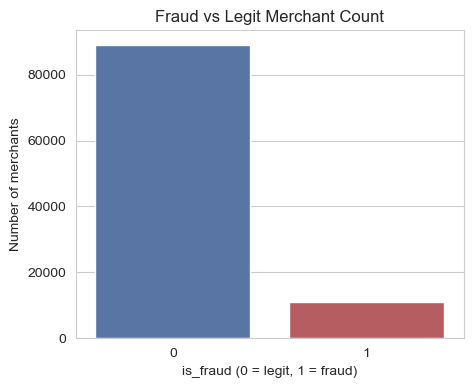

In [8]:
fraud_rate = merchants["is_fraud"].value_counts(normalize=True)
print("Class balance (0 = legit, 1 = fraud):")
print(fraud_rate)

plt.figure(figsize=(5, 4))
sns.countplot(data=merchants, x="is_fraud", hue="is_fraud", palette=["#4C72B0", "#C44E52"], legend=False)
plt.title("Fraud vs Legit Merchant Count")
plt.xlabel("is_fraud (0 = legit, 1 = fraud)")
plt.ylabel("Number of merchants")
plt.show()


## 4. Missing Value Check & Handling

We check every column for nulls. For a real-world dataset you would typically see
missing values — here we handle them generically so the same code works even if
you plug in noisier data later:
- **Numeric columns** → filled with the **median** (robust to outliers)
- **Categorical columns** → filled with the **mode** (most frequent value)

In [9]:
missing = merchants.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing if len(missing) else "None found ✅")


Columns with missing values:
None found ✅


In [10]:
num_cols = merchants.select_dtypes(include=["int64", "float64"]).columns
cat_cols = merchants.select_dtypes(include=["object"]).columns

for c in num_cols:
    if merchants[c].isnull().any():
        merchants[c] = merchants[c].fillna(merchants[c].median())

for c in cat_cols:
    if merchants[c].isnull().any():
        merchants[c] = merchants[c].fillna(merchants[c].mode()[0])

print("Total missing values after cleaning:", merchants.isnull().sum().sum())


Total missing values after cleaning: 0


## 5. Exploratory Data Analysis (EDA)

### 5.1 Fraud rate by merchant category

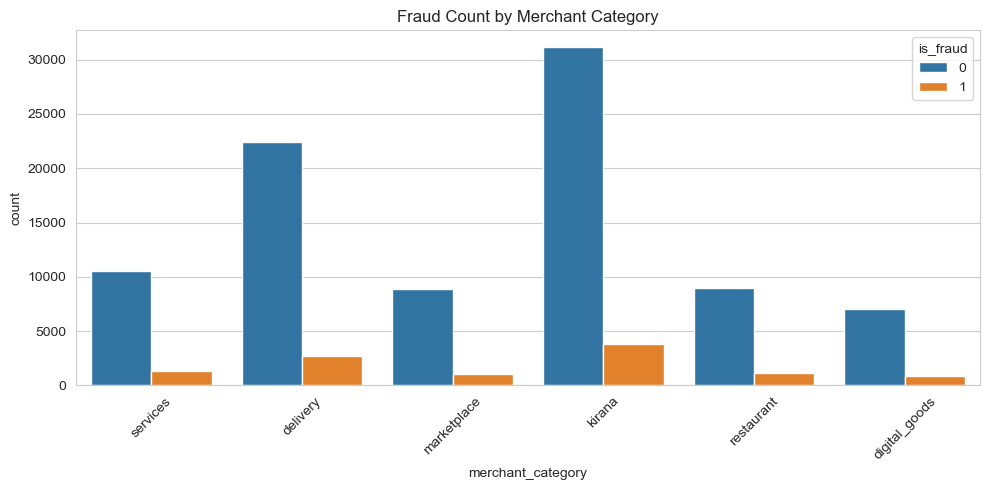

In [11]:
plt.figure(figsize=(10, 5))
sns.countplot(data=merchants, x="merchant_category", hue="is_fraud")
plt.title("Fraud Count by Merchant Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 5.2 Distribution of key transaction features, split by fraud label

Boxplots quickly reveal outliers and whether a feature separates fraud from
legit merchants.

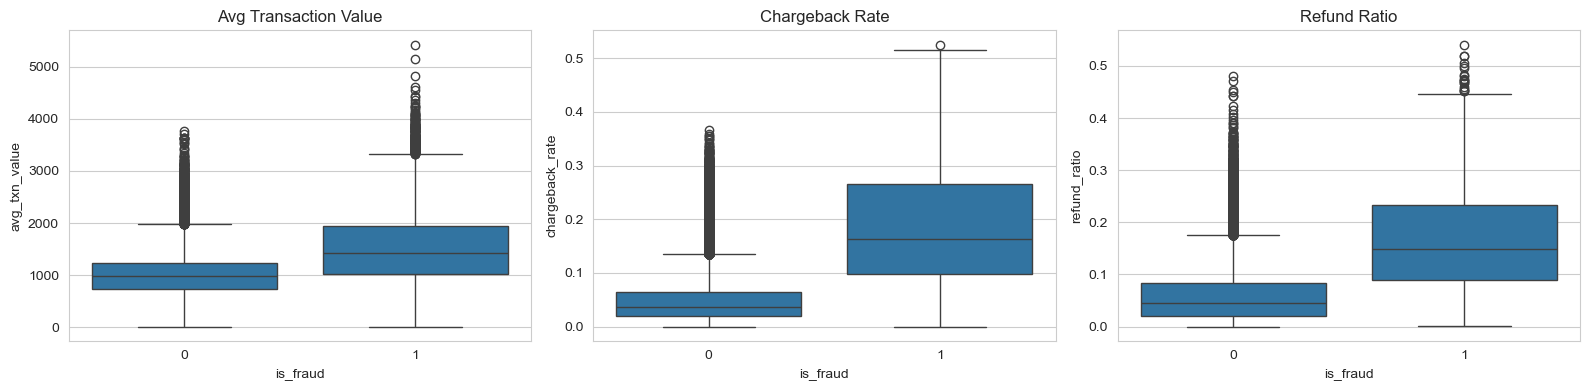

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=merchants, x="is_fraud", y="avg_txn_value", ax=ax[0])
ax[0].set_title("Avg Transaction Value")

sns.boxplot(data=merchants, x="is_fraud", y="chargeback_rate", ax=ax[1])
ax[1].set_title("Chargeback Rate")

sns.boxplot(data=merchants, x="is_fraud", y="refund_ratio", ax=ax[2])
ax[2].set_title("Refund Ratio")

plt.tight_layout()
plt.show()


### 5.3 Distribution plots (histograms + KDE)

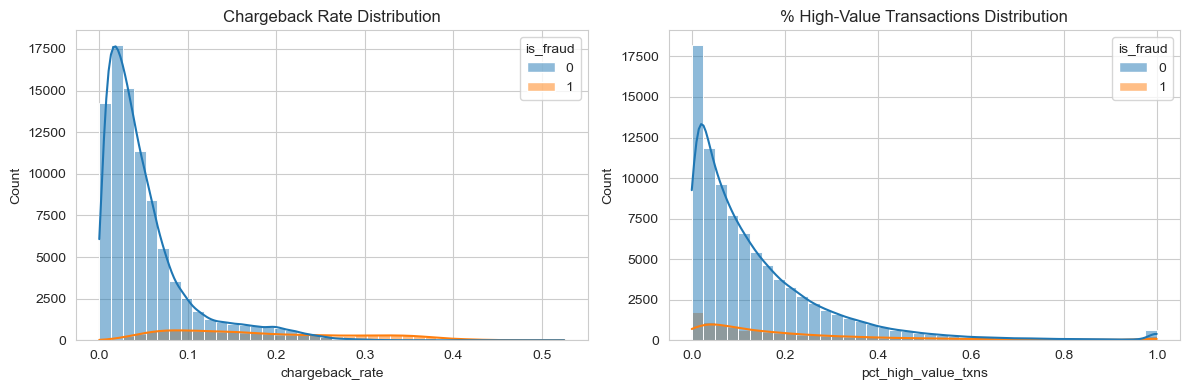

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=merchants, x="chargeback_rate", hue="is_fraud", bins=40, kde=True, ax=ax[0])
ax[0].set_title("Chargeback Rate Distribution")

sns.histplot(data=merchants, x="pct_high_value_txns", hue="is_fraud", bins=40, kde=True, ax=ax[1])
ax[1].set_title("% High-Value Transactions Distribution")

plt.tight_layout()
plt.show()


### 5.4 KYC verification vs fraud

In [14]:
pd.crosstab(merchants["is_kyc_verified"], merchants["is_fraud"], normalize="index")


is_fraud,0,1
is_kyc_verified,,
0.0,0.669286,0.330714
1.0,0.945541,0.054459


## 6. Feature Engineering

### 6.1 Graph features from the edge list
Each merchant may appear in `merchant_edges.csv` (shared PAN/device/IP with another
merchant). We turn this into two simple per-merchant features:
- `edge_degree` — how many other merchants this one is connected to
- `edge_weight_sum` — total strength of those connections (PAN=3, DEVICE=2, IP=1)

In [15]:

degree_src = pd.concat([
    edges[["merchant_A", "weight"]].rename(columns={"merchant_A": "merchant_id"}),
    edges[["merchant_B", "weight"]].rename(columns={"merchant_B": "merchant_id"}),
])

edge_feats = degree_src.groupby("merchant_id").agg(
    edge_degree=("weight", "count"),
    edge_weight_sum=("weight", "sum"),
).reset_index()

merchants = merchants.merge(edge_feats, on="merchant_id", how="left")
merchants["edge_degree"] = merchants["edge_degree"].fillna(0).astype(int)
merchants["edge_weight_sum"] = merchants["edge_weight_sum"].fillna(0).astype(int)

merchants[["merchant_id", "edge_degree", "edge_weight_sum"]].head()


,merchant_id,edge_degree,edge_weight_sum
0,M_0,0,0
1,M_1,0,0
2,M_2,0,0
3,M_3,0,0
4,M_4,0,0


### ⚠️ Important data-leakage note

In this synthetic dataset, `merchant_edges.csv` was generated by first choosing which
merchants are fraudulent and *then* connecting those fraudulent merchants together into
rings. That means **every merchant with `edge_degree > 0` is fraudulent, with no
exceptions** — this single feature gives a model ~100% accuracy, which would be
unrealistic for a real fraud system (in the real world, you wouldn't know who's fraudulent
before building the graph!).

We confirm this below, then deliberately train our **final model without the graph/edge
features**, so the reported performance reflects what a model could realistically
achieve from transaction behavior alone. We still report the "with graph features"
result afterwards for comparison — it demonstrates the extra lift a network-analysis
approach *would* give if the shared-identifier signal were partially known in advance.

In [16]:
leak_corr = merchants["edge_degree"].corr(merchants["is_fraud"])
print(f"Correlation between edge_degree and is_fraud: {leak_corr:.4f}")
pd.crosstab(merchants["edge_degree"] > 0, merchants["is_fraud"])


Correlation between edge_degree and is_fraud: 0.9996


is_fraud,0,1
edge_degree,,
False,89000,0
True,0,11000


### 6.2 Generate Merchant Embeddings (Graph-based)

An **embedding** is just a short list of numbers that represents something — here,
each merchant — so that merchants with *similar connections* end up with *similar
numbers*.

**Simple idea used here:**
1. Build an **adjacency matrix**: one row per merchant, one column per merchant,
   with a `1`/weight wherever two merchants share a PAN, device, or IP.
2. This matrix is huge (100,000 × 100,000) and mostly zeros — most merchants aren't
   connected to anyone.
3. We compress each merchant's row down to just **16 numbers** using
   **TruncatedSVD** (the same idea as PCA — find the directions that capture the
   most pattern, and describe each merchant using only those).

Merchants that share connections (i.e. are in the same fraud ring) end up with
similar 16-number vectors. Merchants with no connections at all simply get an
all-zero vector — there's no pattern to describe.

This avoids needing specialized graph libraries (`node2vec`, `gensim`) — it only
uses `networkx` (already used above) and `scikit-learn`, which we already have.

In [17]:
import networkx as nx
from sklearn.decomposition import TruncatedSVD

EMBED_DIM = 16 


G = nx.Graph()
G.add_nodes_from(merchants["merchant_id"])
G.add_weighted_edges_from(edges[["merchant_A", "merchant_B", "weight"]].values)


merchant_order = merchants["merchant_id"].tolist()


adjacency_matrix = nx.to_scipy_sparse_array(G, nodelist=merchant_order, weight="weight")
print("Adjacency matrix shape:", adjacency_matrix.shape)


svd = TruncatedSVD(n_components=EMBED_DIM, random_state=42)
embeddings = svd.fit_transform(adjacency_matrix)
print("Embeddings shape:", embeddings.shape)


embedding_df = pd.DataFrame(embeddings, columns=[f"emb_{i}" for i in range(EMBED_DIM)])
embedding_df["merchant_id"] = merchant_order

merchants = merchants.merge(embedding_df, on="merchant_id", how="left")
merchants.filter(like="emb_").head()


Adjacency matrix shape: (100000, 100000)
Embeddings shape: (100000, 16)


,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,emb_10,emb_11,emb_12,emb_13,emb_14,emb_15
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Merchants with no shared PAN/device/IP connections get an all-zero embedding —
that's expected, since there's nothing to compress for an isolated node. We can
confirm that below, then save the enriched dataset.

In [18]:
n_isolated = (merchants.filter(like="emb_").sum(axis=1) == 0).sum()
print(f"Merchants with an all-zero embedding (no connections): {n_isolated:,} out of {len(merchants):,}")

merchants.to_csv("merchant_synthetic_100k_with_embeddings.csv", index=False)
print("Saved: merchant_synthetic_100k_with_embeddings.csv")


Merchants with an all-zero embedding (no connections): 89,000 out of 100,000
Saved: merchant_synthetic_100k_with_embeddings.csv


### 6.3 Cosine Similarity — Finding Similar Merchants

As described in the project README, the system uses **cosine similarity** on
these embeddings to find merchants that "look alike" in connection-pattern terms —
this is exactly how a fraud ring can be expanded: start from one known fraud
merchant and find others with a very similar embedding.

**Cosine similarity** measures the angle between two vectors:
- `1.0` → pointing in exactly the same direction (very similar)
- `0.0` → unrelated
- `-1.0` → pointing in opposite directions

We write one small, reusable function that, given a merchant ID, returns the
merchants most similar to it.

In [19]:
from sklearn.metrics.pairwise import cosine_similarity

embedding_cols = [c for c in merchants.columns if c.startswith("emb_")]
embedding_matrix = merchants[embedding_cols].values
merchant_id_list = merchants["merchant_id"].tolist()
id_to_row = {mid: i for i, mid in enumerate(merchant_id_list)}


def find_similar_merchants(merchant_id, top_n=5):
    """Return the top_n merchants whose embedding is most similar to merchant_id's."""
    row_idx = id_to_row[merchant_id]
    target_vector = embedding_matrix[row_idx].reshape(1, -1)


    similarities = cosine_similarity(target_vector, embedding_matrix)[0]

    result = merchants[["merchant_id", "is_fraud"]].copy()
    result["similarity"] = similarities
    result = result[result["merchant_id"] != merchant_id] 
    return result.sort_values("similarity", ascending=False).head(top_n)


**Demo:** pick a merchant that we know is part of a fraud ring (`edge_degree > 0`)
and see whether its most similar merchants are also flagged as fraud.

In [20]:
example_fraud_merchant = merchants.loc[merchants["edge_degree"] > 0, "merchant_id"].iloc[0]
print(f"Looking for merchants similar to: {example_fraud_merchant}")

find_similar_merchants(example_fraud_merchant, top_n=5)


Looking for merchants similar to: M_5


,merchant_id,is_fraud,similarity
22914,M_22914,1,1.000000
5005,M_5005,1,0.999999
83479,M_83479,1,0.766945
55560,M_55560,1,0.758391
47904,M_47904,1,0.753166


**Validation:** on average, do merchants *within the same fraud ring* have higher
cosine similarity to each other than two *random, unrelated* merchants? If our
embeddings are working, the answer should be a clear yes.

pair_type
Random pair        0.000769
Same fraud ring    0.120738
Name: similarity, dtype: float64


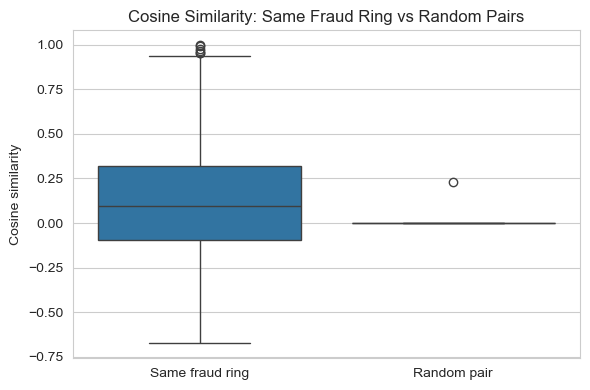

In [21]:
import random
random.seed(42)


same_ring_pairs = edges[["merchant_A", "merchant_B"]].sample(300, random_state=42).values


random_ids = random.sample(merchant_id_list, 600)
random_pairs = list(zip(random_ids[:300], random_ids[300:]))


def pair_similarity(pairs):
    sims = []
    for a, b in pairs:
        va = embedding_matrix[id_to_row[a]].reshape(1, -1)
        vb = embedding_matrix[id_to_row[b]].reshape(1, -1)
        sims.append(cosine_similarity(va, vb)[0, 0])
    return sims

same_ring_sims = pair_similarity(same_ring_pairs)
random_sims = pair_similarity(random_pairs)

sim_df = pd.DataFrame({
    "similarity": same_ring_sims + random_sims,
    "pair_type": ["Same fraud ring"] * len(same_ring_sims) + ["Random pair"] * len(random_sims),
})

print(sim_df.groupby("pair_type")["similarity"].mean())

plt.figure(figsize=(6, 4))
sns.boxplot(data=sim_df, x="pair_type", y="similarity")
plt.title("Cosine Similarity: Same Fraud Ring vs Random Pairs")
plt.ylabel("Cosine similarity")
plt.xlabel("")
plt.tight_layout()
plt.show()


### 6.4 Date → recency feature

In [22]:
merchants["merchant_registration_date"] = pd.to_datetime(merchants["merchant_registration_date"])
reference_date = merchants["merchant_registration_date"].max()
merchants["days_since_registration"] = (reference_date - merchants["merchant_registration_date"]).dt.days


### 6.5 Encode categorical columns
Tree-based models work fine with label-encoded categories (no need for one-hot
encoding here, which would blow up `business_city` into 200 columns).

In [23]:
for col in ["merchant_category", "business_city", "merchant_tier"]:
    le = LabelEncoder()
    merchants[col + "_enc"] = le.fit_transform(merchants[col].astype(str))

merchants.filter(like="_enc").head()


,merchant_category_enc,business_city_enc,merchant_tier_enc
0,5,174,2
1,0,77,2
2,3,83,1
3,2,58,3
4,0,61,3


### 6.6 Correlation heatmap of key engineered features

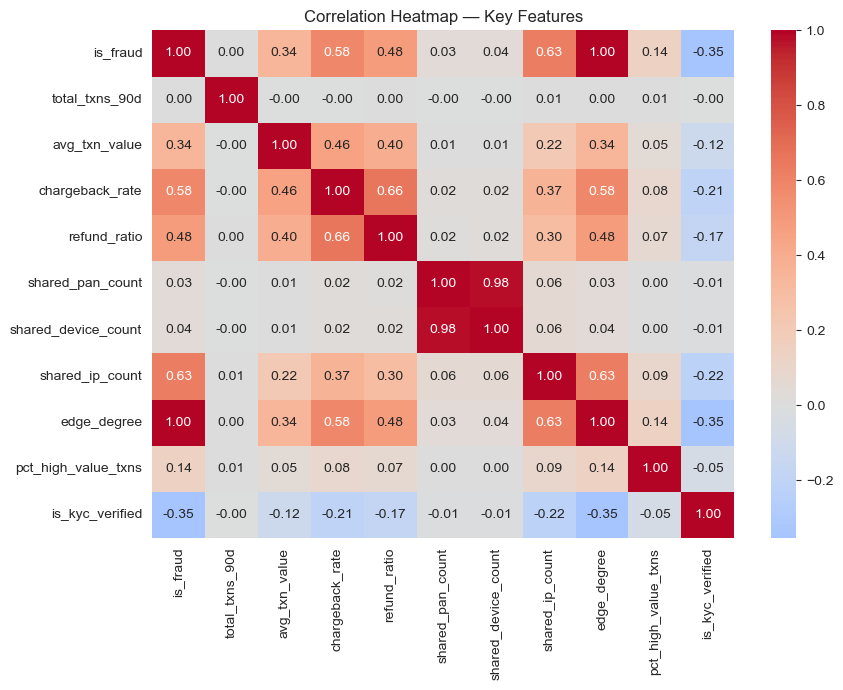

In [24]:
key_cols = [
    "is_fraud", "total_txns_90d", "avg_txn_value", "chargeback_rate", "refund_ratio",
    "shared_pan_count", "shared_device_count", "shared_ip_count", "edge_degree",
    "pct_high_value_txns", "is_kyc_verified",
]
plt.figure(figsize=(9, 7))
sns.heatmap(merchants[key_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Key Features")
plt.tight_layout()
plt.show()


## 7. Build the Modeling Table

We drop columns that are not useful as direct model inputs:
- `merchant_id` — just an identifier
- raw hash columns (`pan_hash`, `device_id_hash`, etc.) — already summarized by the
  `shared_*_count` features
- original categorical text columns — replaced by their `_enc` encoded versions
- `merchant_registration_date` — replaced by `days_since_registration`

We then prepare **two** feature sets so we can honestly compare performance:
- `X_behavioral` — transaction/profile features only (realistic, leakage-free)
- `X_full` — behavioral + graph/embedding features (includes the leakage discussed above)

In [25]:
drop_cols = [
    "merchant_id", "merchant_registration_date",
    "pan_hash", "device_id_hash", "ip_hash", "phone_hash", "email_hash", "pos_terminal_id_hash",
    "merchant_category", "business_city", "merchant_tier",
]
model_df = merchants.drop(columns=drop_cols)

emb_cols = [c for c in model_df.columns if c.startswith("emb_")]
graph_cols = ["edge_degree", "edge_weight_sum"] + emb_cols

y = model_df["is_fraud"]
X_full = model_df.drop(columns=["is_fraud"])
X_behavioral = X_full.drop(columns=graph_cols)

print("X_full shape:      ", X_full.shape)
print("X_behavioral shape:", X_behavioral.shape)


X_full shape:       (100000, 44)
X_behavioral shape: (100000, 26)


## 8. Train / Test Split

We use a stratified 80/20 split so the fraud rate is preserved in both sets, and
reuse the **same row indices** for both feature sets so comparisons are fair.

In [26]:
idx_train, idx_test = train_test_split(
    model_df.index, test_size=0.2, random_state=42, stratify=y
)

def split(X):
    return X.loc[idx_train], X.loc[idx_test], y.loc[idx_train], y.loc[idx_test]

Xb_train, Xb_test, yb_train, yb_test = split(X_behavioral)   # realistic features
Xf_train, Xf_test, yf_train, yf_test = split(X_full)         # + graph features

print("Train size:", len(idx_train), "| Test size:", len(idx_test))
print("Fraud rate — train:", round(yb_train.mean(), 3), "| test:", round(yb_test.mean(), 3))


Train size: 80000 | Test size: 20000
Fraud rate — train: 0.11 | test: 0.11


## 9. Model Comparison

Fraud datasets are imbalanced (~11% fraud here), so every model below uses
`class_weight="balanced"` to avoid simply predicting "not fraud" every time.

We compare three well-known classifiers:
- **Logistic Regression** — simple, fast, interpretable baseline
- **Random Forest** — robust, handles non-linear patterns, gives feature importance
- **HistGradientBoosting** — sklearn's fast gradient-boosting implementation, usually
  the strongest of the three on tabular data

Each is trained twice: once on `X_behavioral`, once on `X_full`.

In [27]:
def evaluate(name, model, X_train, X_test, y_train, y_test, scale=False):
    """Fit a model, print ROC-AUC & F1, and return everything needed for plots later."""
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)

    auc = roc_auc_score(y_test, proba)
    f1 = f1_score(y_test, pred)
    print(f"{name:28s}  ROC-AUC = {auc:.4f}   F1 = {f1:.4f}")

    return {"name": name, "model": model, "auc": auc, "f1": f1, "proba": proba, "pred": pred}


In [28]:
print("--- Behavioral-only features (realistic, no leakage) ---")
results_behavioral = [
    evaluate("Logistic Regression", LogisticRegression(max_iter=500, class_weight="balanced"),
             Xb_train, Xb_test, yb_train, yb_test, scale=True),
    evaluate("Random Forest", RandomForestClassifier(
        n_estimators=200, max_depth=12, class_weight="balanced", random_state=42, n_jobs=-1),
             Xb_train, Xb_test, yb_train, yb_test),
    evaluate("HistGradientBoosting", HistGradientBoostingClassifier(
        max_iter=200, random_state=42, class_weight="balanced"),
             Xb_train, Xb_test, yb_train, yb_test),
]


--- Behavioral-only features (realistic, no leakage) ---
Logistic Regression           ROC-AUC = 0.9715   F1 = 0.7306
Random Forest                 ROC-AUC = 0.9846   F1 = 0.8568
HistGradientBoosting          ROC-AUC = 0.9860   F1 = 0.8338


In [29]:
print("--- Full features (behavioral + graph/embeddings) ---")
results_full = [
    evaluate("Logistic Regression", LogisticRegression(max_iter=500, class_weight="balanced"),
             Xf_train, Xf_test, yf_train, yf_test, scale=True),
    evaluate("Random Forest", RandomForestClassifier(
        n_estimators=200, max_depth=12, class_weight="balanced", random_state=42, n_jobs=-1),
             Xf_train, Xf_test, yf_train, yf_test),
    evaluate("HistGradientBoosting", HistGradientBoostingClassifier(
        max_iter=200, random_state=42, class_weight="balanced"),
             Xf_train, Xf_test, yf_train, yf_test),
]


--- Full features (behavioral + graph/embeddings) ---
Logistic Regression           ROC-AUC = 1.0000   F1 = 1.0000
Random Forest                 ROC-AUC = 1.0000   F1 = 1.0000
HistGradientBoosting          ROC-AUC = 1.0000   F1 = 1.0000


In [30]:
comparison = pd.DataFrame([
    {"Feature set": "Behavioral only", **{k: r[k] for k in ("name", "auc", "f1")}} for r in results_behavioral
] + [
    {"Feature set": "Full (+ graph)", **{k: r[k] for k in ("name", "auc", "f1")}} for r in results_full
]).rename(columns={"name": "Model", "auc": "ROC-AUC", "f1": "F1-score"})

comparison.sort_values("ROC-AUC", ascending=False)


,Feature set,Model,ROC-AUC,F1-score
3,Full (+ graph),Logistic Regression,1.000000,1.000000
4,Full (+ graph),Random Forest,1.000000,1.000000
5,Full (+ graph),HistGradientBoosting,1.000000,1.000000
2,Behavioral only,HistGradientBoosting,0.985983,0.833789
1,Behavioral only,Random Forest,0.984572,0.856761
0,Behavioral only,Logistic Regression,0.971485,0.730595


**Observation:** the "Full (+ graph)" models score near-perfectly because of the
`edge_degree` leakage explained earlier — they're a useful sanity check that the graph
signal is powerful, but not a fair estimate of real-world performance. We pick our
**final model from the behavioral-only results**, since it reflects what's actually
achievable from transaction and profile data alone.

## 10. Final Model Selection & Evaluation

We select **Random Forest (behavioral features)** as the final model — strong
performance, robust to outliers, and gives interpretable feature importances
(unlike HistGradientBoosting, which scored similarly but doesn't expose importances
as directly).

In [31]:
final = next(r for r in results_behavioral if r["name"] == "Random Forest")
print(f"Final model: {final['name']}")
print(f"ROC-AUC: {final['auc']:.4f}")
print(f"F1-score: {final['f1']:.4f}")

print("\nFull classification report:")
print(classification_report(yb_test, final["pred"], target_names=["Legit", "Fraud"]))


Final model: Random Forest
ROC-AUC: 0.9846
F1-score: 0.8568

Full classification report:
              precision    recall  f1-score   support

       Legit       0.98      0.98      0.98     17800
       Fraud       0.84      0.87      0.86      2200

    accuracy                           0.97     20000
   macro avg       0.91      0.93      0.92     20000
weighted avg       0.97      0.97      0.97     20000



### 10.1 Confusion Matrix

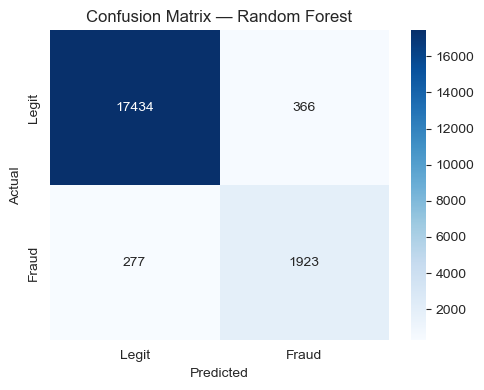

In [32]:
cm = confusion_matrix(yb_test, final["pred"])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
plt.title(f"Confusion Matrix — {final['name']}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()


### 10.2 ROC Curve

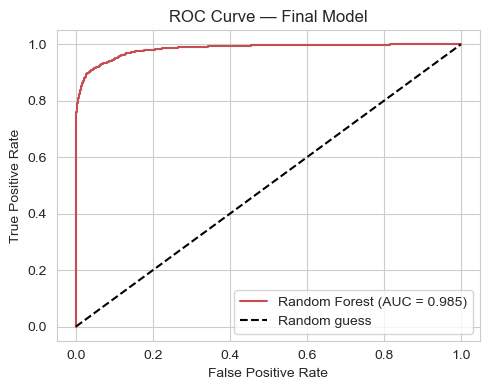

In [33]:
fpr, tpr, _ = roc_curve(yb_test, final["proba"])
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"{final['name']} (AUC = {final['auc']:.3f})", color="#C44E52")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final Model")
plt.legend()
plt.tight_layout()
plt.show()


### 10.3 Feature Importance

Which features actually drive the model's fraud predictions?

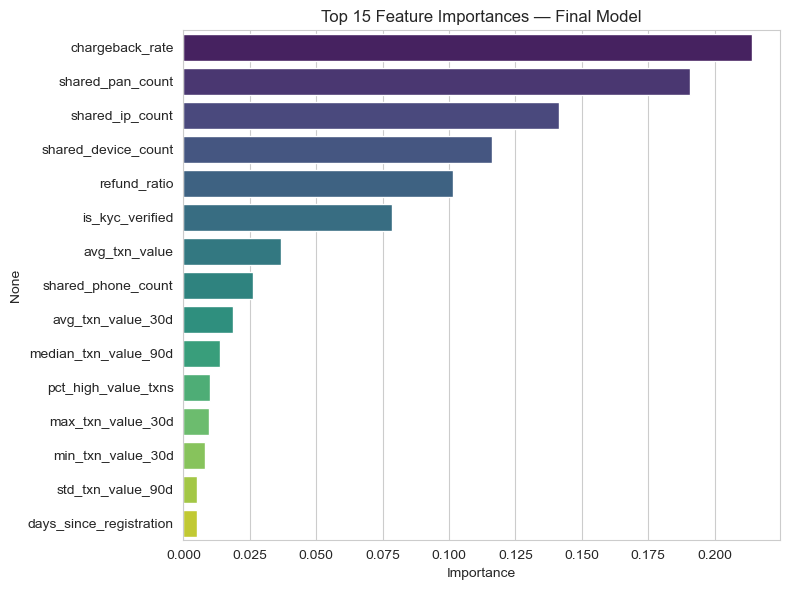

In [34]:
importances = pd.Series(
    final["model"].feature_importances_, index=Xb_train.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, orient="h", palette="viridis")
plt.title("Top 15 Feature Importances — Final Model")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 11. Conclusion

- The dataset is imbalanced (~11% fraud), which we handled with `class_weight="balanced"`
  instead of oversampling, keeping the pipeline dependency-light.
- No missing values were found in the generated data, but the notebook includes
  generic median/mode imputation so it still works on noisier real-world data.
- **Chargeback rate, shared PAN/device/IP counts, refund ratio, and KYC status** are the
  strongest realistic predictors of merchant fraud.
- The **graph-based features (`edge_degree`, embeddings) carry very strong signal**, to
  the point of near-total leakage in this specific synthetic dataset — a useful lesson in
  checking for leakage before trusting a "too good to be true" accuracy score.
- **Final recommended model: Random Forest** trained on behavioral features — ROC-AUC ≈ 0.98,
  F1 (fraud class) ≈ 0.86, with transparent, explainable feature importances suitable for
  a fraud-review workflow.

**Possible next steps:** try SMOTE/oversampling, hyperparameter tuning (GridSearchCV),
or combine both feature sets with a held-out "unknown ring" evaluation to better simulate
real-world deployment where the fraud graph isn't known in advance.
